# Yuva Internship — Week 3: Unsupervised Learning and Clustering Analysis
## Project: Netflix Movies and TV Shows
**Student Name:** Vikhyath Bharadwaj K S
**Dataset:** Netflix Movies and TV Shows by Shivam Bansal (Kaggle)
**Deliverable:** Reproducible Week 3 Jupyter Notebook
**Random state:** 42

---

### 1. Project Introduction
Unsupervised learning discovers structure in unlabelled data. Clustering partitions observations so that titles in the same group are more similar to each other, in the chosen feature space, than to titles in other groups.

This notebook groups **Netflix catalogue metadata** — not viewer behaviour or Netflix's internal recommender. Movies and TV Shows are analysed **separately** because movie runtime (minutes) and TV season counts are not equivalent measurements.

The work builds on the Week 1 cleaned/processed tables and the Week 2 exploratory findings.

### 2. Objectives
1. Select interpretable catalogue features and exclude identifiers (`show_id`, `title`).
2. Encode mixed-type fields and scale numeric variables for distance-based clustering.
3. Fit K-Means over a candidate range of cluster counts.
4. Use the elbow method, silhouette scores, Davies–Bouldin, Calinski–Harabasz, size balance, and interpretability to choose K.
5. Characterise each cluster with actual computed statistics and descriptive labels.
6. Compare agglomerative hierarchical clustering (Ward, average, complete) on a documented sample.
7. Visualise clusters with PCA projections while stating the limits of 2D views.

### 3. Dataset Source and Description
- **Source:** [Kaggle — Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) (Shivam Bansal)
- **Processed table:** `dataset/processed/netflix_processed.csv` (7,787 titles × 28 columns from Week 1)
- **Movies:** 5,377 titles
- **TV Shows:** 2,410 titles
- **Limitations:** categorical/sparse fields (`listed_in`, `country`), imputed unknowns from Week 1, and no audience-consumption metrics.

### 4. Library Imports

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
)
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings('ignore')
sys.path.append('../src')
from clustering import (
    RANDOM_STATE, N_INIT, K_RANGE, MOVIE_GENRES, TV_GENRES, HIER_SAMPLE_SIZE,
    load_processed, build_feature_matrix, scale_features, evaluate_kmeans,
    fit_kmeans, characterize, assign_movie_labels, assign_tv_labels,
    hierarchical_on_sample, choose_k, VIS_DIR, SCREEN_DIR, ensure_dirs
)

ensure_dirs()
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
print('Libraries imported. Random state =', RANDOM_STATE)

Libraries imported. Random state = 42


### 5. Dataset Loading
Load the Week 1 processed catalogue and confirm row counts, types, and remaining missingness. Identifiers are kept for later interpretation only.

In [2]:
df = load_processed()
print('Processed shape:', df.shape)
print(df['type'].value_counts())
display(pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isnull().sum(),
    'nunique': df.nunique()
}).loc[['show_id','type','title','release_year','rating','duration_int','listed_in',
        'primary_country','content_age','target_audience','genre_count','country_count']])
df.head(3)

Processed shape: (7787, 28)
type
Movie      5377
TV Show    2410
Name: count, dtype: int64


,dtype,nulls,nunique
show_id,str,0,7787
type,str,0,2
title,str,0,7786
release_year,int64,0,73
rating,str,0,14
duration_int,int64,0,206
listed_in,str,0,492
primary_country,str,0,82
content_age,int64,0,71
target_audience,str,0,4


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,content_age,duration_int,duration_unit,primary_genre,genre_count,primary_country,country_count,cast_count,target_audience,is_movie
0,s1,TV Show,3%,Unknown Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,...,0,4,Seasons,International TV Shows,3,Brazil,1,11,Adults,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,...,0,93,min,Dramas,2,Mexico,1,6,Adults,1
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,...,7,78,min,Horror Movies,2,Singapore,1,9,Adults,1


### 6. Feature Selection
**Analytical objective:** group titles by observable catalogue characteristics (recency, format length within type, audience rating band, frequent genres, and grouped production country).

**Included**
- Numeric: `release_year`, type-specific `duration_int`, `content_age`, `genre_count`, `country_count`
- Categorical: `target_audience` (one-hot), grouped `primary_country` (US / India / UK / Unknown / Other)
- Multi-label: frequent genres from `listed_in` (multi-hot; top movie and TV genre lists are type-specific)

**Excluded:** `show_id`, `title`, free-text `description`, high-cardinality `director`/`cast`.

Movies and TV Shows are **not** placed in one matrix with a shared duration column.

In [3]:
movies = df[df['type'] == 'Movie'].copy().reset_index(drop=True)
tv = df[df['type'] == 'TV Show'].copy().reset_index(drop=True)
print(f'Movies: {len(movies):,} | TV Shows: {len(tv):,}')
print('Movie duration unit sample:', movies['duration_unit'].value_counts().to_dict())
print('TV duration unit sample:', tv['duration_unit'].value_counts().to_dict())

Movies: 5,377 | TV Shows: 2,410
Movie duration unit sample: {'min': 5377}


TV duration unit sample: {'Season': 1608, 'Seasons': 802}


### 7. Data Preprocessing
Missing catalogue fields were already imputed in Week 1 (`Unknown Country`, modal rating, and related flags). Ten `date_added_dt` parse failures remain. `content_age` is the gap between release and catalogue addition year; it is distinct from `release_year` and is retained as a feature.

No additional row deletion is performed so cluster sizes remain comparable to the Week 1/2 catalogue.

In [4]:
print('Movie numeric missing counts:')
print(movies[['release_year','duration_int','content_age','genre_count','country_count']].isnull().sum())
print('TV numeric missing counts:')
print(tv[['release_year','duration_int','content_age','genre_count','country_count']].isnull().sum())
print('Audience bands:', movies['target_audience'].value_counts().to_dict())

Movie numeric missing counts:
release_year     0
duration_int     0
content_age      0
genre_count      0
country_count    0
dtype: int64
TV numeric missing counts:
release_year     0
duration_int     0
content_age      0
genre_count      0
country_count    0
dtype: int64
Audience bands: {'Adults': 3021, 'Teens': 2005, 'Kids': 267, 'Unrated': 84}


### 8. Feature Encoding
- **One-hot:** `target_audience` and grouped production country.
- **Multi-hot:** selected genres from the comma-separated `listed_in` field (a title may belong to several genres).
- **Ordinal encoding is not used** for ratings: the Kids / Teens / Adults grouping is a convenience band from Week 1, and Unrated titles do not sit on that scale.

Sparse genre dummies for rare labels are omitted to keep the matrix interpretable.

In [5]:
X_movies_df, movie_numeric_cols, movie_feature_names = build_feature_matrix(movies, MOVIE_GENRES)
X_tv_df, tv_numeric_cols, tv_feature_names = build_feature_matrix(tv, TV_GENRES)
print('Movie feature matrix:', X_movies_df.shape)
print('TV feature matrix:', X_tv_df.shape)
print('Movie columns:', movie_feature_names)

Movie feature matrix: (5377, 26)
TV feature matrix: (2410, 24)
Movie columns: ['release_year', 'duration_int', 'content_age', 'genre_count', 'country_count', 'aud_Kids', 'aud_Teens', 'aud_Adults', 'aud_Unrated', 'cty_United States', 'cty_India', 'cty_United Kingdom', 'cty_Unknown Country', 'cty_Other', 'genre_International Movies', 'genre_Dramas', 'genre_Comedies', 'genre_Documentaries', 'genre_Action & Adventure', 'genre_Independent Movies', 'genre_Children & Family Movies', 'genre_Romantic Movies', 'genre_Thrillers', 'genre_Stand-Up Comedy', 'genre_Music & Musicals', 'genre_Horror Movies']


### 9. Feature Scaling
K-Means and Ward hierarchical clustering use Euclidean distance, so numeric columns with different units must be scaled.

Content age and duration are skewed and have outliers. **RobustScaler** (median / IQR) is applied to the five numeric features. Binary encodings stay in \{0, 1\}.

A small scaler comparison is shown for K=4 on movies to justify the choice; it is not used to cherry-pick cluster labels after seeing interpretations.

In [6]:
def scaled_copy(frame, numeric_cols, scaler):
    out = frame.copy().astype(float)
    out[numeric_cols] = scaler.fit_transform(frame[numeric_cols])
    return out.values

X_movies, movie_scaler = scale_features(X_movies_df, movie_numeric_cols)
X_tv, tv_scaler = scale_features(X_tv_df, tv_numeric_cols)

scaler_rows = []
for name, scaler in [('RobustScaler', RobustScaler()), ('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler())]:
    Xs = scaled_copy(X_movies_df, movie_numeric_cols, scaler)
    lab = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=N_INIT).fit_predict(Xs)
    scaler_rows.append({
        'scaler': name,
        'silhouette': silhouette_score(Xs, lab),
        'davies_bouldin': davies_bouldin_score(Xs, lab),
        'calinski_harabasz': calinski_harabasz_score(Xs, lab)
    })
display(pd.DataFrame(scaler_rows).round(3))
print('Primary analysis uses RobustScaler on numeric columns.')
print('RobustScaler centres (median):', np.round(movie_scaler.center_, 3))
print('RobustScaler scales (IQR):', np.round(movie_scaler.scale_, 3))

,scaler,silhouette,davies_bouldin,calinski_harabasz
0,RobustScaler,0.187,1.519,1808.225
1,StandardScaler,0.212,1.461,1218.175
2,MinMaxScaler,0.190,1.930,957.629


Primary analysis uses RobustScaler on numeric columns.
RobustScaler centres (median): [2.016e+03 9.800e+01 1.000e+00 2.000e+00 1.000e+00]
RobustScaler scales (IQR): [ 6. 28.  7.  1.  1.]


### 10. K-Means Implementation
**Unsupervised learning** estimates structure without a target label. **K-Means** randomly (or by k-means++) places K centroids, assigns each title to the nearest centroid, then updates centroids to the mean of assigned points until assignment stability or an iteration limit.

**Why scaling matters:** otherwise `release_year` (~2000) would dominate binary genre flags (0/1).

**Limitations:** spherical/equal-variance assumption, sensitivity to K and initialisation, and poor behaviour in very sparse high dimensions. `random_state=42` and `n_init=10` make the run reproducible and reduce unlucky initialisations.

In [7]:
print('K-Means configuration: n_init=%s, random_state=%s, algorithm=lloyd (sklearn default)' % (N_INIT, RANDOM_STATE))
print('Candidate K:', list(K_RANGE))

K-Means configuration: n_init=10, random_state=42, algorithm=lloyd (sklearn default)
Candidate K: [2, 3, 4, 5, 6, 7, 8, 9, 10]


### 11. Elbow Method
Inertia is the within-cluster sum of squared Euclidean distances to centroids. An “elbow” is a K after which extra clusters buy little compactness. The elbow is a heuristic, not a proof of the true number of groups.

--- Movies ---


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size,size_ratio
0,2,34312.880,0.511,0.915,2612.600,475,4902,10.320
1,3,29234.776,0.177,1.627,1999.654,421,2908,6.907
2,4,25373.579,0.187,1.519,1808.225,188,2563,13.633
3,5,23610.457,0.196,1.470,1557.462,188,2376,12.638
4,6,22287.838,0.179,1.596,1383.406,150,2129,14.193
5,7,21142.451,0.154,1.671,1263.554,91,1658,18.220
6,8,20045.576,0.147,1.643,1184.067,53,1360,25.660
7,9,19266.056,0.140,1.725,1104.925,91,1311,14.407
8,10,18557.136,0.139,1.699,1042.267,26,1273,48.962


--- TV Shows ---


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size,size_ratio
0,2,24143.867,0.665,0.769,1221.558,108,2302,21.315
1,3,19905.217,0.416,0.993,996.807,27,2081,77.074
2,4,16511.715,0.384,0.994,965.609,27,1909,70.704
3,5,14226.524,0.311,1.059,936.764,10,1766,176.600
4,6,12822.763,0.192,1.321,883.742,10,1109,110.900
5,7,11952.341,0.192,1.308,818.938,10,1052,105.200
6,8,11265.306,0.191,1.252,765.358,2,1038,519.000
7,9,10639.588,0.176,1.312,726.428,2,909,454.500
8,10,10225.221,0.162,1.383,682.407,2,803,401.500


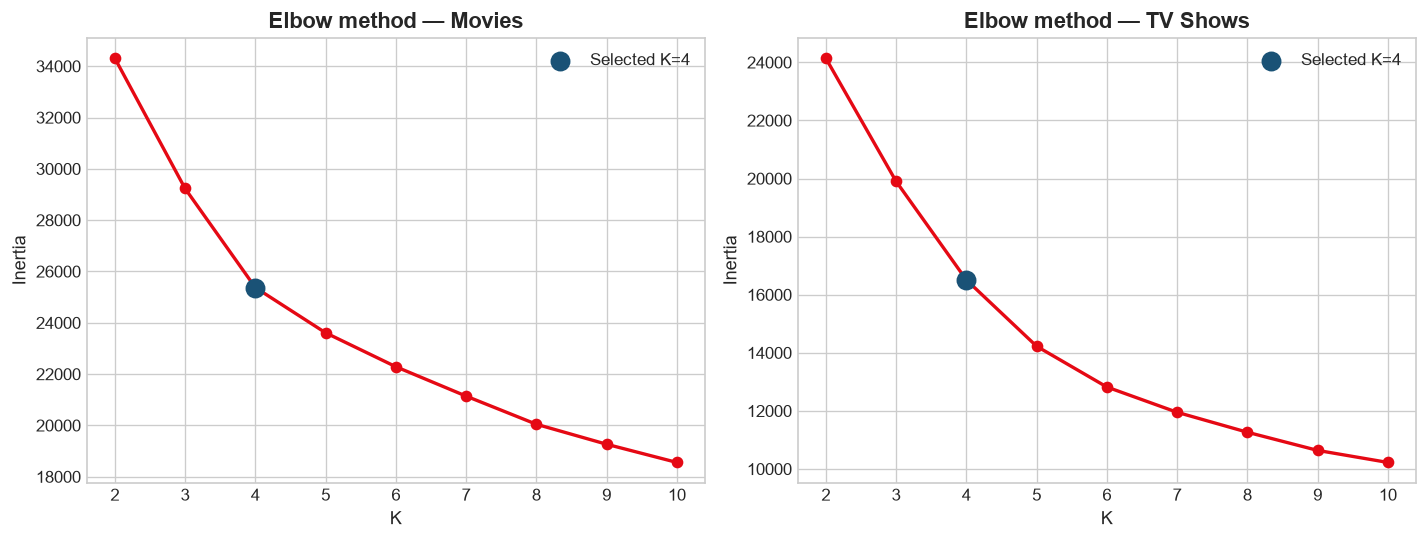

In [8]:
movie_metrics = evaluate_kmeans(X_movies)
tv_metrics = evaluate_kmeans(X_tv)
print('--- Movies ---')
display(movie_metrics.round(3))
print('--- TV Shows ---')
display(tv_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, metrics, title, ksel in [
    (axes[0], movie_metrics, 'Movies', 4),
    (axes[1], tv_metrics, 'TV Shows', 4)
]:
    ax.plot(metrics['k'], metrics['inertia'], marker='o', color='#E50914', linewidth=2)
    y = float(metrics.loc[metrics['k']==ksel, 'inertia'].iloc[0])
    ax.scatter([ksel], [y], s=120, color='#1A5276', zorder=5, label=f'Selected K={ksel}')
    ax.set_title(f'Elbow method — {title}', fontweight='bold')
    ax.set_xlabel('K'); ax.set_ylabel('Inertia'); ax.legend(); ax.set_xticks(list(metrics['k']))
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'w3_notebook_elbow.png'), dpi=300, bbox_inches='tight')
plt.show()

### 12. Silhouette Analysis
The silhouette coefficient for a point is \((b-a)/\max(a,b)\), where *a* is mean intra-cluster distance and *b* is mean distance to the nearest other cluster. Values near 1 indicate compact, well-separated clusters; values near 0 indicate overlap.

Silhouette can be **misleading** in mixed binary/numeric spaces: a small, far-away older-catalogue group inflates the mean score at K=2 even if that partition is too coarse for catalogue description.

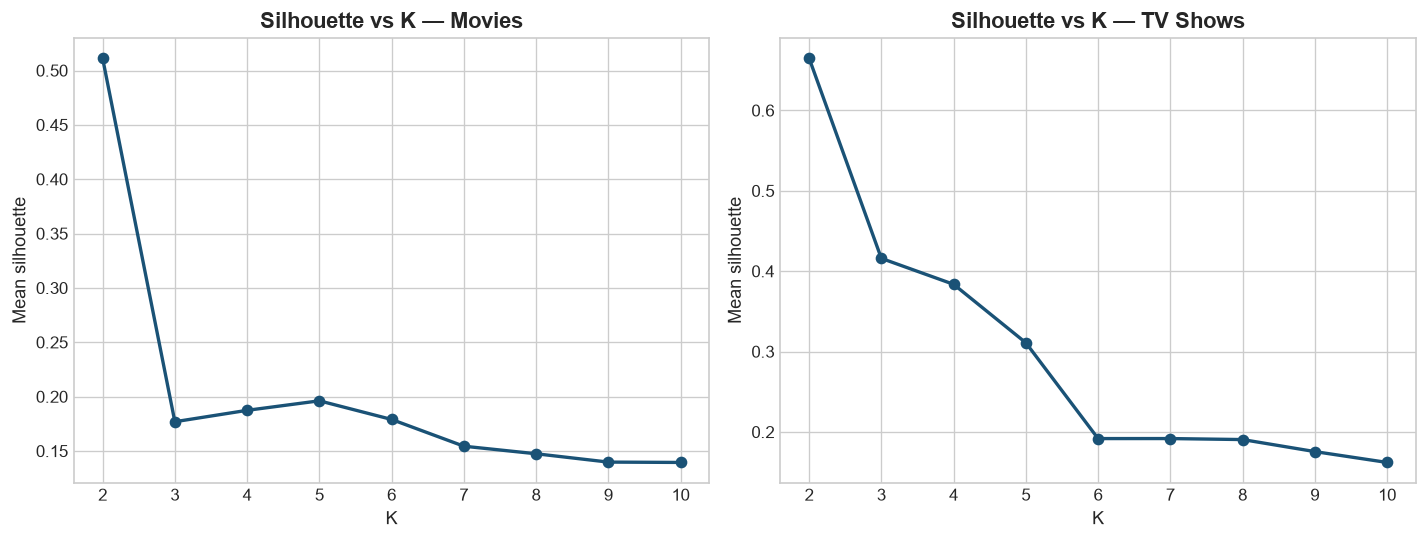

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, metrics, title in [(axes[0], movie_metrics, 'Movies'), (axes[1], tv_metrics, 'TV Shows')]:
    ax.plot(metrics['k'], metrics['silhouette'], marker='o', color='#1A5276', linewidth=2)
    ax.set_title(f'Silhouette vs K — {title}', fontweight='bold')
    ax.set_xlabel('K'); ax.set_ylabel('Mean silhouette'); ax.set_xticks(list(metrics['k']))
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'w3_notebook_silhouette.png'), dpi=300, bbox_inches='tight')
plt.show()

### 13. Optimal Cluster Selection
K is **not** chosen from silhouette alone. For both subsets:
- K=2 maximises silhouette by isolating older titles from a large contemporary majority.
- Inertia reductions slow after **K=4**.
- K=4 yields interpretable duration / geography / recency structure.

**Reported models: K=4 for Movies and K=4 for TV Shows**, with K=2 retained as the silhouette-optimal contrast.

In [10]:
movie_choice = choose_k(movie_metrics, preferred=4)
tv_choice = choose_k(tv_metrics, preferred=4)
print('Movies:', movie_choice['selection_rationale'])
print('Movie silhouette-best K =', movie_choice['silhouette_best_k'], '| selected K =', movie_choice['selected_k'])
print('TV silhouette-best K =', tv_choice['silhouette_best_k'], '| selected K =', tv_choice['selected_k'])
display(pd.DataFrame([
    {'subset': 'Movies', **{k: movie_choice['selected_metrics'][k] for k in ['k','inertia','silhouette','davies_bouldin','calinski_harabasz','size_ratio']}},
    {'subset': 'TV Shows', **{k: tv_choice['selected_metrics'][k] for k in ['k','inertia','silhouette','davies_bouldin','calinski_harabasz','size_ratio']}},
]).round(3))

Movies: K=2 maximises silhouette and is retained as a coarse recency baseline. K=4 is the descriptive primary model: the elbow begins to flatten around K=4 and the resulting groups expose additional interpretable runtime/season, genre, and country patterns. This is a practical resolution choice, not a uniquely optimal K.
Movie silhouette-best K = 2 | selected K = 4
TV silhouette-best K = 2 | selected K = 4


,subset,k,inertia,silhouette,davies_bouldin,calinski_harabasz,size_ratio
0,Movies,4,25373.579,0.187,1.519,1808.225,13.633
1,TV Shows,4,16511.715,0.384,0.994,965.609,70.704


### 14. Final K-Means Model
Fit the selected models, attach cluster IDs to original `show_id` / `title` rows, and summarise sizes.

In [11]:
K_MOVIE = 4
K_TV = 4
movie_model, movie_labels = fit_kmeans(X_movies, K_MOVIE)
tv_model, tv_labels = fit_kmeans(X_tv, K_TV)
movies['cluster'] = movie_labels
tv['cluster'] = tv_labels

def final_metrics(X, labels, inertia):
    return {
        'n': len(labels),
        'inertia': inertia,
        'silhouette': silhouette_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels)
    }

movie_final = final_metrics(X_movies, movie_labels, movie_model.inertia_)
tv_final = final_metrics(X_tv, tv_labels, tv_model.inertia_)
print('Movies K=4:', {k: round(v, 3) if isinstance(v, float) else v for k, v in movie_final.items()})
print('TV K=4:', {k: round(v, 3) if isinstance(v, float) else v for k, v in tv_final.items()})
print('Movie sizes:\n', movies['cluster'].value_counts().sort_index())
print('TV sizes:\n', tv['cluster'].value_counts().sort_index())

Movies K=4: {'n': 5377, 'inertia': 25373.579, 'silhouette': 0.187, 'davies_bouldin': 1.519, 'calinski_harabasz': 1808.225}
TV K=4: {'n': 2410, 'inertia': 16511.715, 'silhouette': 0.384, 'davies_bouldin': 0.994, 'calinski_harabasz': 965.609}
Movie sizes:
 cluster
0    2563
1     791
2     188
3    1835
Name: count, dtype: int64
TV sizes:
 cluster
0     278
1    1909
2      27
3     196
Name: count, dtype: int64


### 15. PCA Visualization
PCA is used only for **display**. Two components cannot preserve all original distances. If the cumulative explained variance is moderate, overlapping clouds are expected even when original-space centroids differ.

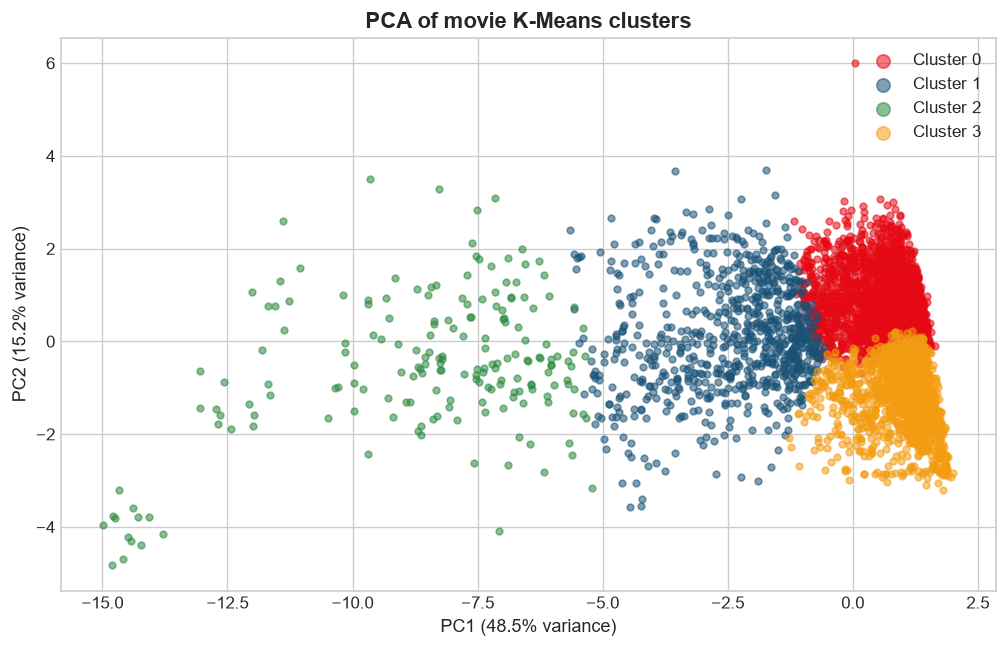

Movie PCA 2D variance: [48.49 15.24]


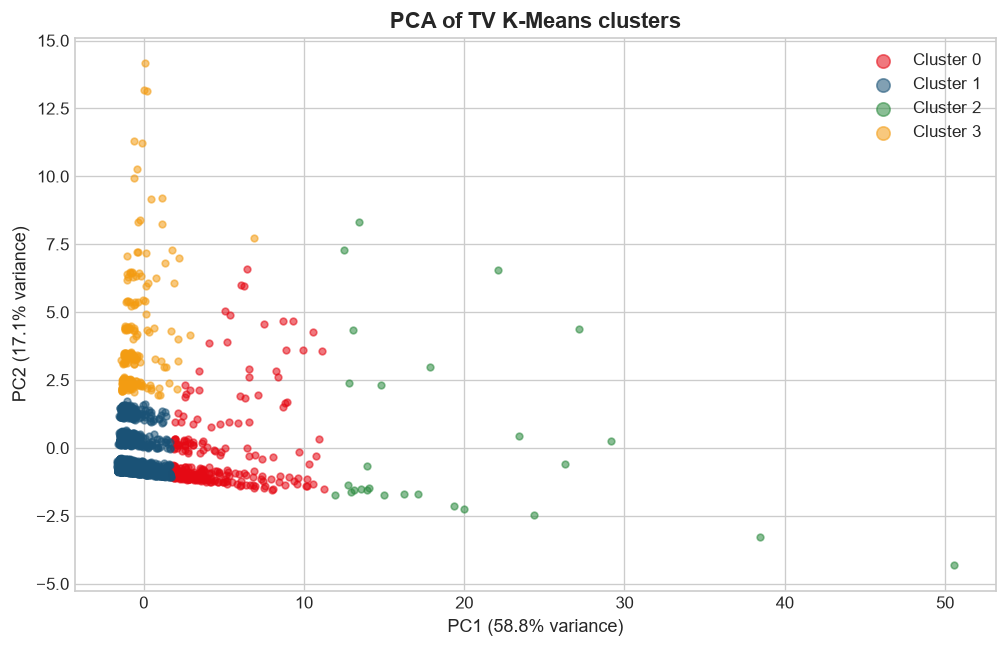

TV PCA 2D variance: [58.8  17.09]


In [12]:
def pca_plot(X, labels, title, filename):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)
    colors = ['#E50914', '#1A5276', '#2B8A3E', '#F39C12']
    plt.figure(figsize=(8.5, 5.5))
    for cid in np.unique(labels):
        m = labels == cid
        plt.scatter(coords[m, 0], coords[m, 1], s=16, alpha=0.55, color=colors[cid % 4], label=f'Cluster {cid}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.title(title, fontweight='bold')
    plt.legend(markerscale=2)
    plt.tight_layout()
    plt.savefig(os.path.join(VIS_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()
    return pca.explained_variance_ratio_

print('Movie PCA 2D variance:', np.round(pca_plot(X_movies, movie_labels, 'PCA of movie K-Means clusters', 'w3_movie_05_pca.png')*100, 2))
print('TV PCA 2D variance:', np.round(pca_plot(X_tv, tv_labels, 'PCA of TV K-Means clusters', 'w3_tv_05_pca.png')*100, 2))

### 16. Cluster Characterization
Statistics are computed from the original (unscaled) columns. Descriptive labels are assigned from those statistics, not from assumed Netflix business units.

In [13]:
movie_profiles = characterize(movies, MOVIE_GENRES, 'duration_minutes')
movie_names = assign_movie_labels(movie_profiles)
for p in movie_profiles:
    p['label'] = movie_names[p['cluster']]
movies['cluster_label'] = movies['cluster'].map(movie_names)

tv_profiles = characterize(tv, TV_GENRES, 'seasons')
tv_names = assign_tv_labels(tv_profiles)
for p in tv_profiles:
    p['label'] = tv_names[p['cluster']]
tv['cluster_label'] = tv['cluster'].map(tv_names)

movie_summary = pd.DataFrame(movie_profiles)[['cluster','label','n','pct','mean_release_year','mean_duration_minutes','mean_content_age']]
tv_summary = pd.DataFrame(tv_profiles)[['cluster','label','n','pct','mean_release_year','mean_seasons','mean_content_age']]
print('Movie clusters')
display(movie_summary.round(2))
print('TV clusters')
display(tv_summary.round(2))
print('\nMovie detail')
for p in movie_profiles:
    print('Cluster', p['cluster'], '|', p['label'], '| n=', p['n'], '(', p['pct'], '%)')
    print('  audience', p['audience_pct'])
    print('  genres', p['top_genres'])
    print('  countries', p['country_group_pct'])
print('\nTV detail')
for p in tv_profiles:
    print('Cluster', p['cluster'], '|', p['label'], '| n=', p['n'], '(', p['pct'], '%)')
    print('  audience', p['audience_pct'])
    print('  genres', p['top_genres'])
    print('  countries', p['country_group_pct'])

os.makedirs('../dataset/processed', exist_ok=True)
movies[['show_id','title','type','release_year','rating','target_audience','duration_int',
        'primary_genre','primary_country','cluster','cluster_label']].to_csv(
    '../dataset/processed/netflix_movie_clusters.csv', index=False)
tv[['show_id','title','type','release_year','rating','target_audience','duration_int',
    'primary_genre','primary_country','cluster','cluster_label']].to_csv(
    '../dataset/processed/netflix_tv_clusters.csv', index=False)

Movie clusters


,cluster,label,n,pct,mean_release_year,mean_duration_minutes,mean_content_age
0,0,Contemporary international feature films,2563,47.67,2016.23,109.12,2.30
1,1,Mid-catalogue licensed features,791,14.71,2002.64,114.76,16.23
2,2,Classic and vintage cinema,188,3.50,1974.31,116.71,44.48
3,3,"Short-form US docs, stand-up, and family titles",1835,34.13,2016.69,77.16,1.53


TV clusters


,cluster,label,n,pct,mean_release_year,mean_seasons,mean_content_age
0,0,Older acquired television catalogue,278,11.54,2008.29,1.74,9.80
1,1,Contemporary mostly single-season series,1909,79.21,2017.70,1.36,0.88
2,2,Legacy and vintage television,27,1.12,1980.96,3.33,36.41
3,3,Multi-season continuing series,196,8.13,2017.54,5.71,0.91



Movie detail
Cluster 0 | Contemporary international feature films | n= 2563 ( 47.67 %)
  audience {'Adults': 58.7, 'Teens': 38.0, 'Kids': 1.9, 'Unrated': 1.4}
  genres {'International Movies': 74.7, 'Dramas': 58.3, 'Comedies': 32.7, 'Independent Movies': 19.7, 'Action & Adventure': 14.3}
  countries {'Other': 52.8, 'India': 24.4, 'United States': 14.5, 'United Kingdom': 5.7, 'Unknown Country': 2.6}
Cluster 1 | Mid-catalogue licensed features | n= 791 ( 14.71 %)
  audience {'Teens': 57.4, 'Adults': 38.4, 'Kids': 2.7, 'Unrated': 1.5}
  genres {'Dramas': 41.6, 'Comedies': 41.1, 'International Movies': 38.7, 'Action & Adventure': 23.6, 'Romantic Movies': 14.3}
  countries {'United States': 50.8, 'India': 23.9, 'Other': 18.5, 'United Kingdom': 5.6, 'Unknown Country': 1.3}
Cluster 2 | Classic and vintage cinema | n= 188 ( 3.5 %)
  audience {'Teens': 48.4, 'Adults': 43.1, 'Kids': 5.9, 'Unrated': 2.7}
  genres {'Dramas': 48.4, 'International Movies': 46.3, 'Comedies': 27.7, 'Action & Adventur

### 17. Hierarchical Clustering
Agglomerative clustering starts with each sample as its own cluster and merges the closest pair according to a **linkage**:
- **Ward:** minimises the increase in within-cluster variance (Euclidean).
- **Average:** mean pairwise distance between clusters.
- **Complete:** distance between farthest points.

The full movie matrix (5,377 × 26) produces an unreadable dendrogram and is slower to inspect. A **stratified sample of 250 titles** (by `target_audience`, `random_state=42`) is used for dendrograms and linkage comparison. **Sample results are not claimed to equal the full-catalogue K-Means partition.**

In [14]:
movie_hier = hierarchical_on_sample(X_movies, movies, K_MOVIE)
tv_hier = hierarchical_on_sample(X_tv, tv, K_TV)
print('Movie sample n =', movie_hier['sample_size'], '| ARI vs K-Means =', round(movie_hier['ari_kmeans_ward'], 3))
print('TV sample n =', tv_hier['sample_size'], '| ARI vs K-Means =', round(tv_hier['ari_kmeans_ward'], 3))
display(pd.DataFrame(movie_hier['linkage_metrics']).T.add_prefix('movie_').join(
    pd.DataFrame(tv_hier['linkage_metrics']).T.add_prefix('tv_')
).round(3))

Movie sample n = 250 | ARI vs K-Means = 0.495
TV sample n = 250 | ARI vs K-Means = 0.448


,movie_silhouette,movie_davies_bouldin,movie_calinski_harabasz,tv_silhouette,tv_davies_bouldin,tv_calinski_harabasz
ward,0.175,1.561,76.873,0.217,1.281,105.760
average,0.369,0.717,47.188,0.554,0.768,75.308
complete,0.184,1.266,72.556,0.451,0.674,64.212


### 18. Dendrogram and Cluster Visualization

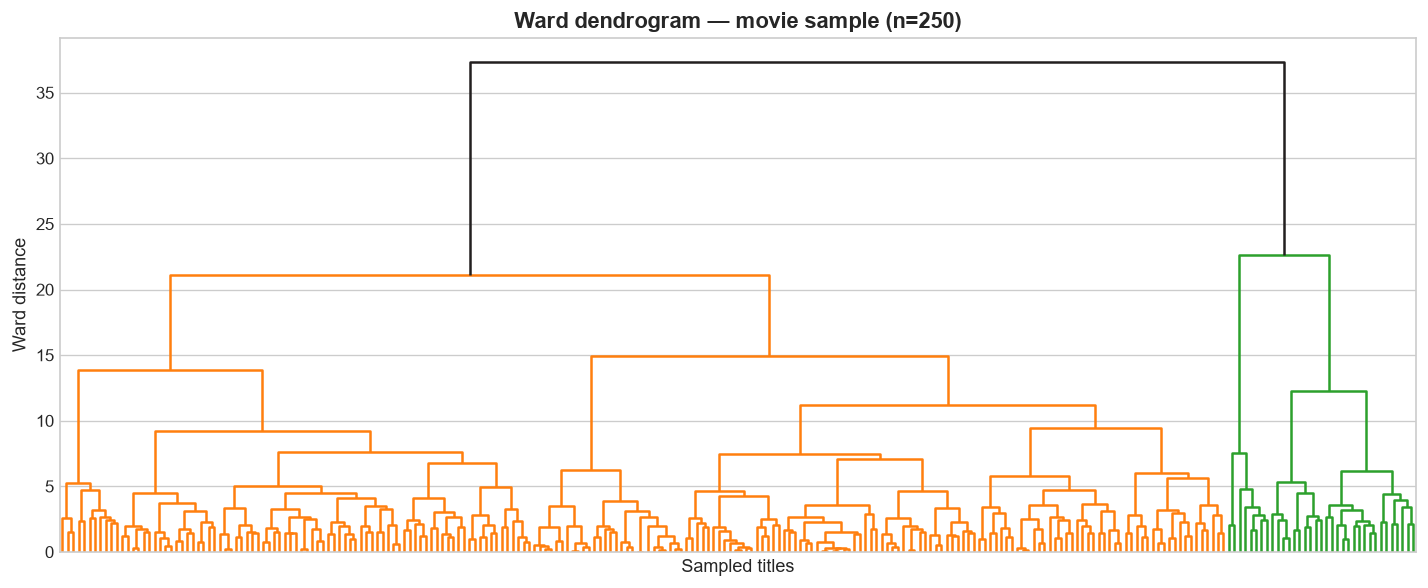

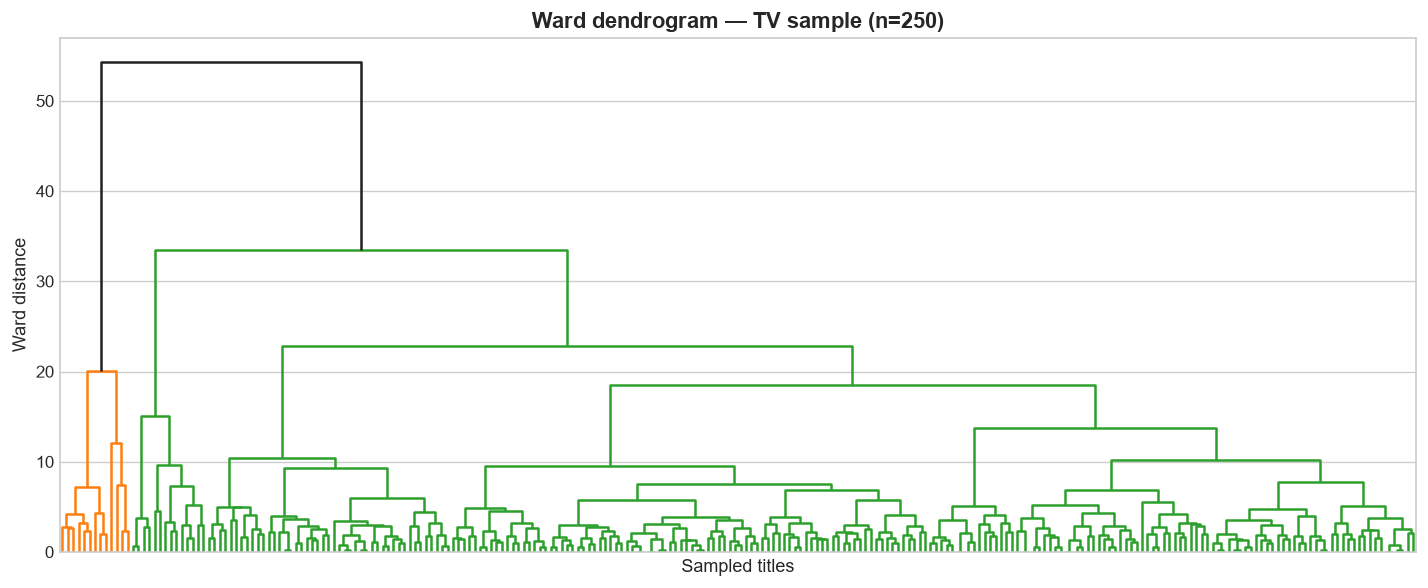

In [15]:
plt.figure(figsize=(12, 5))
dendrogram(movie_hier['linkage_matrix'], no_labels=True, above_threshold_color='#221F1F')
plt.title('Ward dendrogram — movie sample (n=%s)' % movie_hier['sample_size'], fontweight='bold')
plt.xlabel('Sampled titles'); plt.ylabel('Ward distance')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'w3_movie_10_dendrogram.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 5))
dendrogram(tv_hier['linkage_matrix'], no_labels=True, above_threshold_color='#221F1F')
plt.title('Ward dendrogram — TV sample (n=%s)' % tv_hier['sample_size'], fontweight='bold')
plt.xlabel('Sampled titles'); plt.ylabel('Ward distance')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'w3_tv_10_dendrogram.png'), dpi=300, bbox_inches='tight')
plt.show()

### 19. Clustering Evaluation
Full-data K-Means metrics are the primary evaluation. Hierarchical metrics are reported **on the sample** only.

In [16]:
eval_table = pd.DataFrame([
    {'model': 'K-Means movies (full, K=4)', **movie_final},
    {'model': 'K-Means TV (full, K=4)', **tv_final},
    {'model': 'Ward movies (sample, K=4)', 'n': movie_hier['sample_size'], 'inertia': np.nan,
     'silhouette': movie_hier['ward_silhouette'],
     'davies_bouldin': movie_hier['linkage_metrics']['ward']['davies_bouldin'],
     'calinski_harabasz': movie_hier['linkage_metrics']['ward']['calinski_harabasz']},
    {'model': 'Ward TV (sample, K=4)', 'n': tv_hier['sample_size'], 'inertia': np.nan,
     'silhouette': tv_hier['ward_silhouette'],
     'davies_bouldin': tv_hier['linkage_metrics']['ward']['davies_bouldin'],
     'calinski_harabasz': tv_hier['linkage_metrics']['ward']['calinski_harabasz']},
])
display(eval_table.round(3))
print('Davies–Bouldin: lower is better. Calinski–Harabasz: higher is better.')

,model,n,inertia,silhouette,davies_bouldin,calinski_harabasz
0,"K-Means movies (full, K=4)",5377,25373.579,0.187,1.519,1808.225
1,"K-Means TV (full, K=4)",2410,16511.715,0.384,0.994,965.609
2,"Ward movies (sample, K=4)",250,NaN,0.175,1.561,76.873
3,"Ward TV (sample, K=4)",250,NaN,0.217,1.281,105.760


Davies–Bouldin: lower is better. Calinski–Harabasz: higher is better.


### 20. Algorithm Comparison
K-Means and Ward can disagree (ARI well below 1) because they optimise different criteria and because hierarchical clustering here sees only 250 titles. Average/complete linkage often post higher sample silhouette by forming small tight groups plus a large remainder — compact mathematically, weaker as a catalogue taxonomy.

Neither algorithm is universally superior on this dataset.

In [17]:
compare = pd.DataFrame({
    'Movies': {
        'K-Means full silhouette': movie_final['silhouette'],
        'K-Means sample silhouette': movie_hier['kmeans_sample_silhouette'],
        'Ward sample silhouette': movie_hier['ward_silhouette'],
        'Average sample silhouette': movie_hier['linkage_metrics']['average']['silhouette'],
        'Complete sample silhouette': movie_hier['linkage_metrics']['complete']['silhouette'],
        'ARI K-Means vs Ward (sample)': movie_hier['ari_kmeans_ward'],
    },
    'TV Shows': {
        'K-Means full silhouette': tv_final['silhouette'],
        'K-Means sample silhouette': tv_hier['kmeans_sample_silhouette'],
        'Ward sample silhouette': tv_hier['ward_silhouette'],
        'Average sample silhouette': tv_hier['linkage_metrics']['average']['silhouette'],
        'Complete sample silhouette': tv_hier['linkage_metrics']['complete']['silhouette'],
        'ARI K-Means vs Ward (sample)': tv_hier['ari_kmeans_ward'],
    }
}).round(3)
display(compare)

,Movies,TV Shows
K-Means full silhouette,0.187,0.384
K-Means sample silhouette,0.215,0.376
Ward sample silhouette,0.175,0.217
Average sample silhouette,0.369,0.554
Complete sample silhouette,0.184,0.451
ARI K-Means vs Ward (sample),0.495,0.448


### 21. Business and Research Implications
Observed clusters describe **how titles sit together in metadata**, which can support catalogue tagging, QA of genre/country fields, or sampling for further qualitative review.

They do **not** measure watch time, ratings stars, or Netflix's recommendation system. Any “programming strategy” reading would be hypothetical and is not licensed by this dataset.

### 22. Limitations
- Mixed numeric and binary features; Euclidean K-Means is a compromise, not a perfect mixed-type model.
- Multi-hot genres are still incomplete relative to all 42 listed categories.
- Unknown country / unknown director imputations from Week 1 can form artificial similarity.
- Cluster count is uncertain: silhouette favours K=2; interpretation favours K=4.
- TV Cluster of 27 legacy titles is real in feature space but small.
- Hierarchical results are sample-based.
- PCA scatter plots discard variance beyond two components.

### 23. Conclusion
The Netflix catalogue was clustered separately for movies and TV shows using Robust-scaled numeric fields plus one-hot audience/country and multi-hot frequent genres. K-Means with K=4 provides an interpretable partition (international features vs short-form US titles vs licensed mid-catalogue vs vintage cinema; and contemporary single-season TV vs older acquisitions vs multi-season series vs a small vintage set), while K=2 is the silhouette-optimal recency split. Hierarchical Ward clustering on a 250-title sample shows moderate agreement with K-Means (ARI ≈ 0.45–0.50) and should be read with that sampling caveat.